# Visualização do custo logístico

Lê a aba da tabela cruzada (**`Tabela Final`** ou **`Tabela_Final`** — o nome é detetado automaticamente) em **`Exercicio recrutamento Finalizado.xlsx`** (versão final com a tabela materializada; não o ficheiro intermédio `Exercicio recrutamento.xlsx`) e reproduz a mesma lógica do Excel:

- **Custo fixo:** faixa `KmMin`–`KmMax` + veículo + região  
- **Custo variável:** faixas de paradas `0–60`, `61–90`, `91+`

**Gráficos:**

1. **Custo total × KM** — **um único painel** para o veículo definido em `VEICULO_PADRAO` (por defeito o primeiro da lista); **uma linha por região**; **paradas fixas**.
2. **Custo total × paradas** — **um único painel** para o mesmo veículo; **uma linha por região**; **KM fixo** editável.

Altere `VEICULO_PADRAO` na primeira célula (e as constantes nas células de plot) para outros cenários.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
EXCEL_PATH = ROOT / "Exercicio recrutamento Finalizado.xlsx"
if not EXCEL_PATH.is_file():
    raise FileNotFoundError(f"Coloque {EXCEL_PATH.name} na pasta do projeto (versão final do workbook).")
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


from matplotlib import ticker as mticker


def regiao_colors(n: int) -> np.ndarray:
    """Paleta contínua com bom contraste para várias regiões."""
    return plt.cm.turbo(np.linspace(0.08, 0.93, max(int(n), 1)))


def style_axes(ax) -> None:
    ax.set_facecolor("#f4f6fb")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color("#cbd5e1")
    ax.spines["left"].set_color("#cbd5e1")
    ax.tick_params(colors="#64748b", labelsize=10)
    ax.grid(True, linestyle=(0, (1, 4)), linewidth=0.85, alpha=0.5, color="#94a3b8")
    ax.set_axisbelow(True)


def format_axis_brl(ax) -> None:
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", "."))
    )


def resolve_final_sheet(xl: pd.ExcelFile) -> str:
    """Localiza aba 'Tabela Final' ou 'Tabela_Final' (espaço vs underscore, maiúsculas)."""

    def norm(s: str) -> str:
        return "".join(c.lower() for c in s if c.isalnum())

    target = norm("Tabela Final")
    for name in xl.sheet_names:
        if norm(name) == target:
            return name
    raise ValueError(
        "Nenhuma aba equivalente a 'Tabela Final'. Abas no ficheiro: "
        + ", ".join(repr(s) for s in xl.sheet_names)
    )


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    expected = [
        "MacroRegiao",
        "Regiao",
        "Veiculo",
        "KmMin",
        "KmMax",
        "CustoFixo",
        "Vlr_0_60",
        "Vlr_61_90",
        "Vlr_91_mais",
    ]
    if len(df.columns) != len(expected):
        raise ValueError(f"Esperadas {len(expected)} colunas, veio {len(df.columns)}.")
    out = df.copy()
    out.columns = expected
    for c in ("Regiao", "Veiculo", "MacroRegiao"):
        out[c] = out[c].astype(str).str.strip()
    return out


def custo_variavel(paradas: float, v1: float, v2: float, v3: float) -> float:
    p = float(paradas)
    q1 = min(p, 60)
    q2 = max(0.0, min(p - 60, 30))
    q3 = max(0.0, p - 90)
    return q1 * v1 + q2 * v2 + q3 * v3


def buscar_linha(df: pd.DataFrame, regiao: str, veiculo: str, km: float) -> pd.Series | None:
    m = (
        (df["Regiao"] == regiao.strip())
        & (df["Veiculo"] == veiculo.strip())
        & (df["KmMin"] <= km)
        & (df["KmMax"] >= km)
    )
    hit = df.loc[m]
    if hit.empty:
        return None
    return hit.iloc[0]


def custo_total(df: pd.DataFrame, regiao: str, veiculo: str, km: float, paradas: float) -> float:
    row = buscar_linha(df, regiao, veiculo, km)
    if row is None:
        return np.nan
    cf = float(row["CustoFixo"])
    v = custo_variavel(paradas, row["Vlr_0_60"], row["Vlr_61_90"], row["Vlr_91_mais"])
    return cf + v


xl_file = pd.ExcelFile(EXCEL_PATH)
SHEET = resolve_final_sheet(xl_file)
print(f"Aba usada: {SHEET!r}")
df = xl_file.parse(SHEET)
df = normalize_columns(df)
veiculos = sorted(df["Veiculo"].unique())
regioes = sorted(df["Regiao"].unique())
print("Veículos:", veiculos)
print("Regiões:", len(regioes))
VEICULO_PADRAO = veiculos[0]  # gráficos: um painel por figura (troque aqui)


Aba usada: 'Tabela_Final'
Veículos: ['Risco', 'Utilitário', 'Van', 'Vuc']
Regiões: 12


## 1. Custo total × KM (um painel; linhas = regiões)

`VEICULO_PADRAO`: por defeito é `veiculos[0]` (lista já ordenada na primeira célula); altere para outro texto igual a um elemento de `veiculos`.

`PARADAS_FIXAS_KM`: número de paradas **fixo** para todos os pontos do eixo KM.


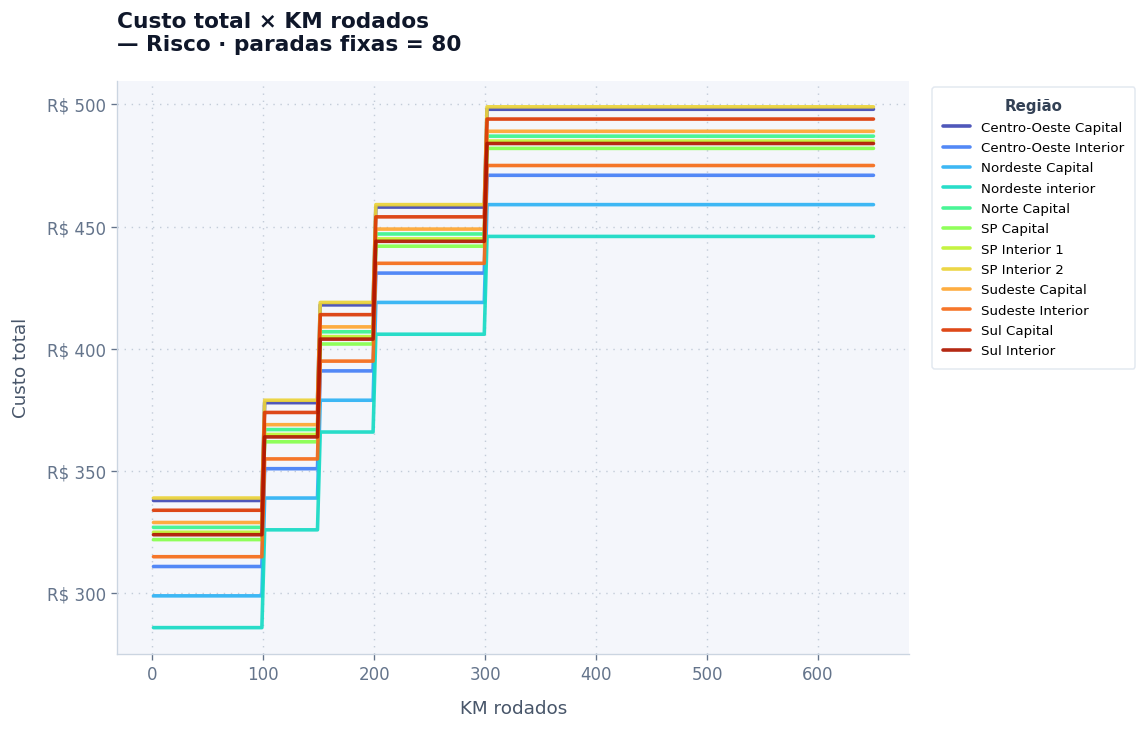

Salvo: c:\Users\lucia\OneDrive\Documentos\GitHub\logistics-cost-calculation-excel-case\figures\nb_km_por_veiculo_linhas_regiao.png


In [9]:
PARADAS_FIXAS_KM = 80
kms = np.linspace(1, 650, 260)

colors = regiao_colors(len(regioes))
fig1, ax1 = plt.subplots(figsize=(11, 6.2), dpi=120)
fig1.patch.set_facecolor("#ffffff")

for i, regiao in enumerate(regioes):
    ys = [custo_total(df, regiao, VEICULO_PADRAO, km, PARADAS_FIXAS_KM) for km in kms]
    if np.all(np.isnan(ys)):
        continue
    ax1.plot(
        kms,
        ys,
        label=regiao,
        color=colors[i],
        linewidth=2.15,
        alpha=0.93,
        solid_capstyle="round",
        solid_joinstyle="round",
    )

style_axes(ax1)
format_axis_brl(ax1)
ax1.set_title(
    f"Custo total × KM rodados\n— {VEICULO_PADRAO} · paradas fixas = {PARADAS_FIXAS_KM:g}",
    fontsize=13,
    fontweight="600",
    color="#0f172a",
    loc="left",
    pad=18,
)
ax1.set_xlabel("KM rodados", fontsize=11, color="#475569", labelpad=10)
ax1.set_ylabel("Custo total", fontsize=11, color="#475569", labelpad=10)

leg = ax1.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title="Região",
    title_fontsize=9,
    frameon=True,
    fancybox=True,
    shadow=False,
    borderpad=0.85,
    labelspacing=0.55,
    columnspacing=1.0,
)
leg.get_frame().set_facecolor("#ffffff")
leg.get_frame().set_edgecolor("#e2e8f0")
leg.get_frame().set_linewidth(0.9)
leg.get_frame().set_alpha(0.98)
leg.get_title().set_fontweight("600")
leg.get_title().set_color("#334155")

fig1.subplots_adjust(right=0.725)
fig1.savefig(
    FIG_DIR / "nb_km_por_veiculo_linhas_regiao.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=fig1.get_facecolor(),
    edgecolor="none",
)
plt.show()
print("Salvo:", FIG_DIR / "nb_km_por_veiculo_linhas_regiao.png")


## 2. Custo total × paradas (um painel; linhas = regiões)

`VEICULO_PADRAO`: o mesmo conceito que acima (por defeito o primeiro veículo).

`KM_FIXO_PARADAS`: quilometragem **fixa** (250).


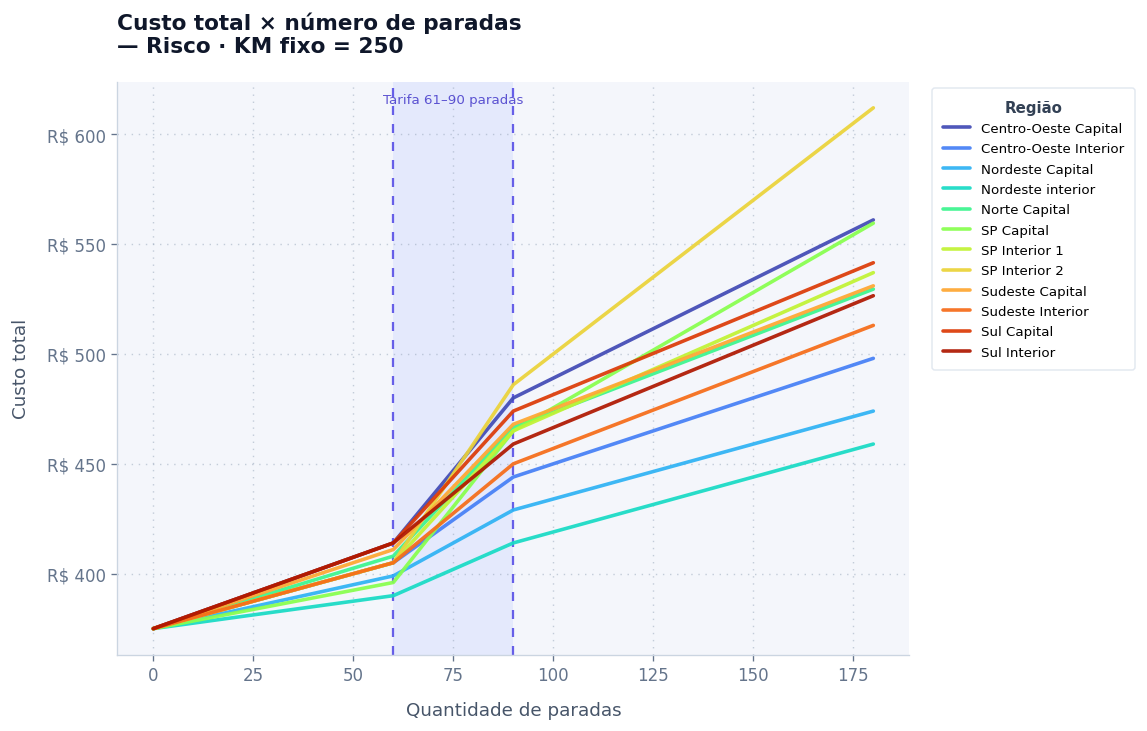

Salvo: c:\Users\lucia\OneDrive\Documentos\GitHub\logistics-cost-calculation-excel-case\figures\nb_paradas_por_veiculo_linhas_regiao.png


In [10]:
KM_FIXO_PARADAS = 250
paradas_grid = np.linspace(0, 180, 361)

colors = regiao_colors(len(regioes))
fig2, ax2 = plt.subplots(figsize=(11, 6.2), dpi=120)
fig2.patch.set_facecolor("#ffffff")

ax2.axvspan(60, 90, facecolor="#c7d2fe", alpha=0.35, zorder=0, linewidth=0)
ax2.axvline(60, color="#4f46e5", linestyle=(0, (4, 4)), linewidth=1.35, alpha=0.85, zorder=1)
ax2.axvline(90, color="#4f46e5", linestyle=(0, (4, 4)), linewidth=1.35, alpha=0.85, zorder=1)

for i, regiao in enumerate(regioes):
    ys = [custo_total(df, regiao, VEICULO_PADRAO, KM_FIXO_PARADAS, p) for p in paradas_grid]
    if np.all(np.isnan(ys)):
        continue
    ax2.plot(
        paradas_grid,
        ys,
        label=regiao,
        color=colors[i],
        linewidth=2.15,
        alpha=0.93,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=2,
    )

style_axes(ax2)
format_axis_brl(ax2)
ax2.set_title(
    f"Custo total × número de paradas\n— {VEICULO_PADRAO} · KM fixo = {KM_FIXO_PARADAS:g}",
    fontsize=13,
    fontweight="600",
    color="#0f172a",
    loc="left",
    pad=18,
)
ax2.set_xlabel("Quantidade de paradas", fontsize=11, color="#475569", labelpad=10)
ax2.set_ylabel("Custo total", fontsize=11, color="#475569", labelpad=10)

ymin, ymax = ax2.get_ylim()
ax2.text(
    75,
    ymax - 0.02 * (ymax - ymin),
    "Tarifa 61–90 paradas",
    ha="center",
    va="top",
    fontsize=8,
    color="#4338ca",
    fontweight="500",
    alpha=0.85,
)

leg = ax2.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title="Região",
    title_fontsize=9,
    frameon=True,
    fancybox=True,
    shadow=False,
    borderpad=0.85,
    labelspacing=0.55,
    columnspacing=1.0,
)
leg.get_frame().set_facecolor("#ffffff")
leg.get_frame().set_edgecolor("#e2e8f0")
leg.get_frame().set_linewidth(0.9)
leg.get_frame().set_alpha(0.98)
leg.get_title().set_fontweight("600")
leg.get_title().set_color("#334155")

fig2.subplots_adjust(right=0.725)
fig2.savefig(
    FIG_DIR / "nb_paradas_por_veiculo_linhas_regiao.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=fig2.get_facecolor(),
    edgecolor="none",
)
plt.show()
print("Salvo:", FIG_DIR / "nb_paradas_por_veiculo_linhas_regiao.png")
